Geostatistics and plotting for spatial anlaysis between faults and predicted SCD locations

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shapely
from shapely.geometry import box
from scipy.spatial import cKDTree
import scienceplots
import seaborn as sns

plt.rcParams["font.family"] = "Arial"
sns.set_theme(style="darkgrid")

fault_path = "../../../datastore/spatial_analysis/FaultsFinal.shp"
object_path = '../../../datastore/spatial_analysis/CentroidsFinal.shp'

# raster extent from colab (could have been non-rectangular but alas it was rectangular)
# changed to fault extent

# crs (bng)
AOI_CRS = "EPSG:27700"

# mc config
N_RANDOM = 100000
N_SIM = 5000
SEED = 42


faults = gpd.read_file(fault_path)

objects = gpd.read_file(object_path)

working_crs = "EPSG:27700"
objects = objects.to_crs(working_crs)
faults = faults.to_crs(working_crs)

bounds = faults.total_bounds
study_area = box(*bounds)
display(working_crs)

'EPSG:27700'

In [3]:
faults

,NoteType,Name,Notes,geometry
0,0,None,None,"LINESTRING Z (308910.062 143185.832 0, 308953...."
1,0,None,None,"LINESTRING Z (306175.171 143340.336 0, 306389...."
2,0,None,None,"LINESTRING Z (303397.211 143849.138 0, 303575...."
3,0,None,None,"LINESTRING Z (303470.871 143872.029 0, 303530...."
4,0,None,None,"LINESTRING Z (303382.066 143368.766 0, 303704...."
...,...,...,...,...
131,0,None,None,"LINESTRING Z (302522.181 140335.855 0, 303603...."
132,0,None,None,"LINESTRING Z (304730.15 141246.107 0, 304901.3..."
133,0,None,None,"LINESTRING Z (298253.434 142483.27 0, 299177.0..."
134,0,None,None,"LINESTRING Z (299199.286 141593.584 0, 298965...."


In [4]:
idx = faults.geometry.length.idxmax()
WCH_Fault = faults.loc[idx]

In [5]:
objects

,object_id,area_m2,ORIG_FID,geometry
0,1.0,178.0,0,POINT (331927.45 154655.982)
1,2.0,151.0,1,POINT (336552.62 153884.781)
2,3.0,337.0,2,POINT (330934.368 149572.712)
3,4.0,686.0,3,POINT (338894.072 147818.987)
4,5.0,484.0,4,POINT (339790.234 146967.576)
...,...,...,...,...
367,382.0,554.0,381,POINT (323462.137 120632.681)
368,383.0,733.0,382,POINT (311836.648 120772.533)
369,384.0,264.0,383,POINT (323633.13 120606.866)
370,385.0,249.0,384,POINT (318356.756 120543.854)


In [6]:
# restrict objects to AOI (centroids derived from a larger DEM pass compared to where faults are mapped)
# centroids already derived in QGIS
inside = objects.within(study_area)
centroids = objects.loc[inside].copy()

In [7]:
centroids

,object_id,area_m2,ORIG_FID,geometry
7,8.0,464.0,7,POINT (319482.315 144616.919)
8,12.0,4400.0,11,POINT (326336.959 144017.477)
9,24.0,267.0,23,POINT (330803.401 143403.888)
10,25.0,638.0,24,POINT (313118.188 143557.738)
11,26.0,560.0,25,POINT (313528.638 143266.912)
...,...,...,...,...
367,382.0,554.0,381,POINT (323462.137 120632.681)
368,383.0,733.0,382,POINT (311836.648 120772.533)
369,384.0,264.0,383,POINT (323633.13 120606.866)
370,385.0,249.0,384,POINT (318356.756 120543.854)


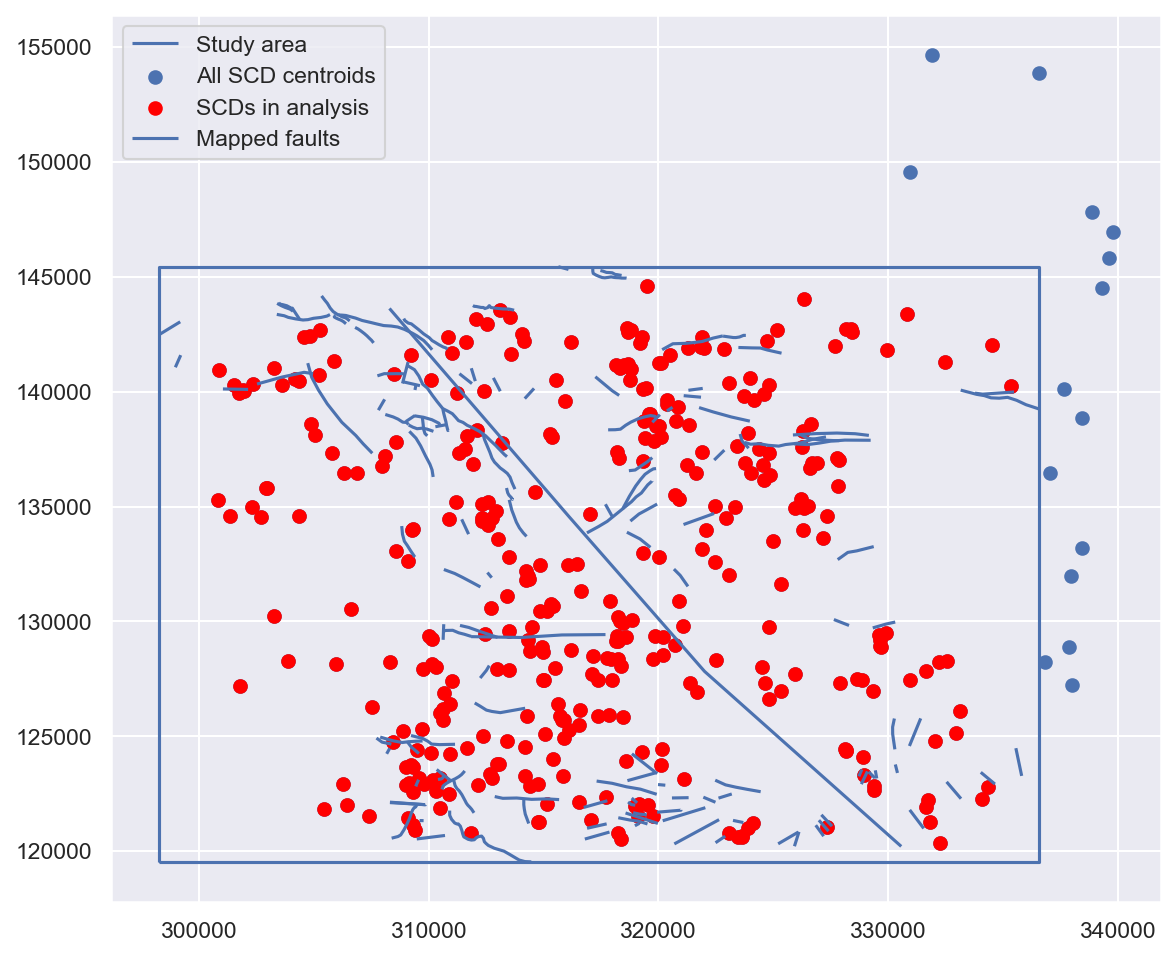

In [8]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=150)

# ChatGPT code in plotting with gpd!

# AOI boundary
gpd.GeoSeries([study_area], crs=working_crs).boundary.plot(ax=ax, label="Study area")
# all detected objects, including those rejected by AOI
objects.plot( ax=ax, label="All SCD centroids")
# centroids actually used in analysis
centroids.plot(ax=ax, color="red", label="SCDs in analysis")
# mapped faults
faults.plot(ax=ax, label="Mapped faults")

ax.set_aspect("equal")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# merge all fault lines into one geometry (so nearest fault simply becomes distance to merged fault object)
fault_union = faults.geometry.union_all()

# get distance to faults from each centroid
centroids["fault_distance_m"] = (centroids.geometry.distance(fault_union))

observed_distances_m = (centroids["fault_distance_m"].to_numpy())
observed_distances_km = ( observed_distances_m / 1000)

In [11]:
# random point generator 
def random_points_in_polygon(polygon, n, rng):

    minx, miny, maxx, maxy = polygon.bounds

    accepted = []
    total = 0

    while total < n:

        remaining = n - total

        # oversample slightly as generated points can be slighlty outside AOI 
        batch_size = max(int(remaining * 1.5),1000)

        # generate random x points in AOI 
        xs = rng.uniform(minx, maxx, batch_size)
        ys = rng.uniform(miny, maxy, batch_size )

        # generate points from inputted x and y coord lists
        points = shapely.points(xs, ys)

        # only keep points within AOI (hence oversampling)
        keep = shapely.contains(polygon, points)

        valid = points[keep]
        accepted.append(valid)
        total += len(valid)

    return np.concatenate(accepted)[:n]

In [12]:
# utilise function above to generate random background statisitics

rng = np.random.default_rng(SEED)

# create 100,000 (N_random) points for MC to sample from
random_points = random_points_in_polygon(study_area, N_RANDOM, rng)

# to sample from in MC
random_distances_m = shapely.distance(random_points,fault_union )
random_distances_km = (random_distances_m / 1000)


In [13]:
# cumulative distributions

# furthest point in whole dataset to generate distance grid
max_distance = max(observed_distances_km.max(), random_distances_km.max())

distance_grid = np.linspace(0, max_distance, 500)


def empirical_cdf(values, grid):

    values = np.sort(values)

    return (np.searchsorted(values, grid, side="right") / len(values))


observed_cdf = empirical_cdf(observed_distances_km, distance_grid)

random_cdf = empirical_cdf(random_distances_km, distance_grid)

In [14]:
# MC

N_OBJECTS = len(observed_distances_km)

sim_cdfs = np.empty((N_SIM, len(distance_grid)),dtype=np.float32)

# run simulations
for i in range(N_SIM):

    # sample some (N_objects, aka 210) from 100,000 generated points
    sim_distances = rng.choice(
        random_distances_km,
        size=N_OBJECTS,
        replace=True)

    sim_cdfs[i] = empirical_cdf(sim_distances, distance_grid)

In [15]:
# Observed statistics
# AI assistance in MC code generation for statistically analysis of the results / h0 rejection, etc.

difference = (observed_cdf - random_cdf)

# Positive means more SCDs occur near faults
observed_stat_one_sided = (np.max(difference))

# Simulation statistics

sim_difference = (sim_cdfs - random_cdf[None, :])
sim_stats_one_sided = np.max(sim_difference, axis=1)

# Monte Carlo p-values
p_one_sided = (np.sum(sim_stats_one_sided >= observed_stat_one_sided) + 1) / (N_SIM + 1)

print(f"\nOne-sided statistic: "
    f"{observed_stat_one_sided:.4f}")

print(
    f"Monte Carlo p (closer to faults): "
    f"{p_one_sided:.5f}")



One-sided statistic: 0.2200
Monte Carlo p (closer to faults): 0.00020


In [16]:
from scipy.stats import ks_2samp

ks = ks_2samp(
    observed_distances_km,
    random_distances_km,
    alternative="greater"
)

print(f"KS D+ = {ks.statistic:.4f}")
print(f"p-value = {ks.pvalue:.6g}")
print(f"Maximum separation at = {ks.statistic_location:.3f} km")

KS D+ = 0.2206
p-value = 7.93139e-16
Maximum separation at = 1.758 km


In [17]:
# confidence envelope for plotting

lower_cdf = np.percentile(sim_cdfs, 2.5, axis=0)
upper_cdf = np.percentile(sim_cdfs, 97.5, axis=0)

In [18]:
# cumulative wealth ratio
# ChatGPT assistance on code generation


wealth_ratio = np.divide(observed_cdf, random_cdf,
                         out=np.full_like(observed_cdf, np.nan),
                          where=random_cdf > 0)

# Avoid interpreting ratios where essentially no random area exists yet (ChatGPT idea, comment, code for below line)
valid_ratio = ((random_cdf >= 0.01)& np.isfinite(wealth_ratio))

In [19]:
# peak enrichment
peak_idx = np.nanargmax(np.where(valid_ratio, wealth_ratio, np.nan))

peak_distance = distance_grid[peak_idx]
peak_wealth = wealth_ratio[peak_idx]
peak_fraction = observed_cdf[peak_idx]

print( f"Peak enrichment Distance = {peak_distance:.2f} km")
print(f"Wealth ratio = {peak_wealth:.2f}")
print(f"SCDs within distance = " f"{peak_fraction * 100:.1f}%")

Peak enrichment Distance = 1.12 km
Wealth ratio = 1.40
SCDs within distance = 66.1%


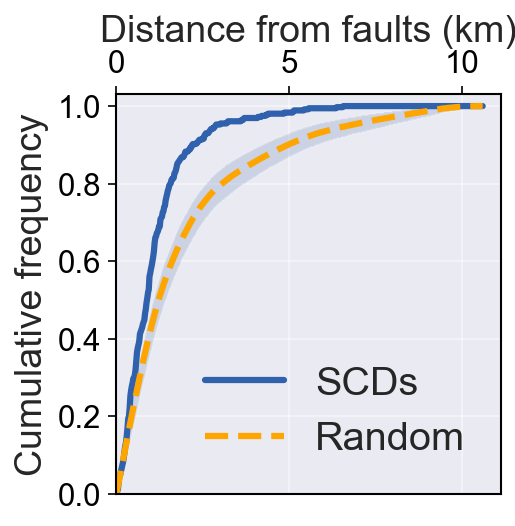

In [20]:
# plot

fig, ax = plt.subplots(figsize=(3.6, 3.6), dpi=150)

plt.rcParams["font.family"] = "Arial"

# chatgpt assistance with plotting
# confidence envelope
ax.fill_between(
    distance_grid,
    lower_cdf,
    upper_cdf,
    alpha=0.20,
)

# line for observed cdf
ax.plot(
    distance_grid,
    observed_cdf,
    linewidth=3,
    label="SCDs",
    color = "#2f61ad"
)

# random 
ax.plot(
    distance_grid,
    random_cdf,
    linestyle="--",
    linewidth=3,
    label="Random",
    color = 'orange'
)

ax.set_xlabel("Distance from faults (km)", fontsize=18)
ax.set_ylabel("Cumulative frequency", fontsize=18)

ax.set_ylim(0, 1.03)
ax.set_xlim(left=0)
ax.legend(frameon=False, fontsize=19)


ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    bottom=True,
    left=True,
    top=False,
    right=False,
    length=4,
    width=0.8,
    color="black",
    labelcolor="black",
    labelsize=15
)

plt.grid(alpha=0.4)
plt.tight_layout()

ax.spines["top"].set_color("black")
ax.spines["top"].set_linewidth(1)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(1)
ax.spines["right"].set_color("black")
ax.spines["right"].set_linewidth(1)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(1)

ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

ax.tick_params(
    axis="x",
    top=True,
    labeltop=True,
    bottom=False,
    labelbottom=False
)

plt.savefig('out/Fig5b.svg', dpi = 300)